<a href="https://colab.research.google.com/github/Abdula3469/Laba/blob/main/Copy_of_7_Advanced_Text_Generation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#7. Продвинутые техники генерации текста и инструменты

---

## Содержание

1. Введение в продвинутые техники генерации
2. Шаблоны промптов (Prompt Templates)
3. Последовательные цепочки (Sequential Chains)
4. Память разговора (Conversation Memory)
5. Типы памяти: буферная, оконная, суммарная
6. Агенты и инструменты (ReAct паттерн)
7. Практический конвейер генерации
8. Самостоятельные задания

## 1. Введение в продвинутые техники генерации

В предыдущей главе мы изучили основы промпт-инженерии. Теперь перейдем
к более сложным паттернам, которые позволяют строить многоступенчатые
системы генерации текста.

Ключевые концепции этой главы:

- **Шаблоны промптов**: переиспользуемые заготовки с переменными.
- **Цепочки (Chains)**: последовательное соединение нескольких вызовов модели.
- **Память разговора**: сохранение контекста между обменами репликами.
- **Агенты**: модели, способные выбирать и вызывать инструменты.

Мы реализуем все эти паттерны с нуля, используя GPT-2 и чистый Python,
чтобы понять внутреннюю механику.

## 2. Шаблоны промптов (Prompt Templates)

Шаблон промпта -- это строка с заполнителями, которые подставляются
перед отправкой в модель. Это позволяет переиспользовать одну и ту же
структуру запроса для разных входных данных.

In [ ]:
# Установка зависимостей (раскомментируйте при необходимости)
# !pip install transformers torch matplotlib numpy -q

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Фиксируем случайное зерно
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Загрузка модели
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

def generate_text(prompt, max_new_tokens=50, temperature=0.7, do_sample=True):
    """Генерация текста с помощью GPT-2."""
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Модель GPT-2 загружена.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Модель GPT-2 загружена.


In [ ]:
class PromptTemplate:
    """Шаблон промпта с именованными переменными."""

    def __init__(self, template, variables):
        """
        Параметры:
            template: строка с заполнителями вида {имя_переменной}
            variables: список имен переменных
        """
        self.template = template
        self.variables = variables

    def format(self, **kwargs):
        """Подставить значения переменных в шаблон."""
        missing = set(self.variables) - set(kwargs.keys())
        if missing:
            raise ValueError(f"Отсутствуют переменные: {missing}")
        return self.template.format(**kwargs)

    def __repr__(self):
        return f"PromptTemplate(variables={self.variables})"


# Пример использования
summary_template = PromptTemplate(
    template="Write a brief summary of {topic} in the context of {field}.\nSummary:",
    variables=["topic", "field"]
)

# Генерация с разными параметрами
prompts_data = [
    {"topic": "neural networks", "field": "medicine"},
    {"topic": "data analysis", "field": "finance"},
    {"topic": "automation", "field": "manufacturing"},
]

for data in prompts_data:
    prompt = summary_template.format(**data)
    result = generate_text(prompt, max_new_tokens=40, temperature=0.5)
    print(f"Тема: {data['topic']}, Область: {data['field']}")
    generated_part = result[len(prompt):]
    print(f"Результат: {generated_part.strip()}")
    print()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Тема: neural networks, Область: medicine
Результат: The aim of this paper is to outline the neural network architecture of the human brain and to describe how it is designed to act as a model of the human brain. The main focus of this paper is

Тема: data analysis, Область: finance
Результат: In this article, we will focus on the first three steps of data analysis. First, we will look at the role of the data source, the data set, and the data set in the

Тема: automation, Область: manufacturing
Результат: Automation is a process by which we automate a product or service, and then we automate the process of making that product or service. Most of the time, it's done by hand, but there



## 3. Последовательные цепочки (Sequential Chains)

Цепочка -- это последовательность шагов, где выход одного шага
используется как вход для следующего. Это позволяет разбивать
сложные задачи на управляемые подзадачи.

Схема работы цепочки:
```
Вход -> [Шаг 1] -> промежуточный результат -> [Шаг 2] -> ... -> [Шаг N] -> Выход
```

In [ ]:
class Chain:
    """Последовательная цепочка шагов генерации."""

    def __init__(self, steps):
        """
        Параметры:
            steps: список кортежей (имя_шага, шаблон, функция_обработки)
        """
        self.steps = steps

    def run(self, initial_input, verbose=True):
        """Выполнить цепочку."""
        current_input = initial_input
        results = {}

        for step_name, template, processor in self.steps:
            if verbose:
                print(f"--- Шаг: {step_name} ---")

            # Формируем промпт
            prompt = template.format(**current_input)

            # Генерируем текст
            raw_output = generate_text(prompt, max_new_tokens=60, temperature=0.5)
            generated = raw_output[len(prompt):].strip()

            # Обрабатываем результат
            if processor:
                processed = processor(generated)
            else:
                processed = generated

            if verbose:
                print(f"Результат: {processed}")
                print()

            results[step_name] = processed
            current_input.update({step_name + "_output": processed})

        return results


# Определяем цепочку для анализа текста
analysis_chain = Chain([
    (
        "extract_topic",
        PromptTemplate(
            "Identify the main topic of this text in one word: {text}\nTopic:",
            ["text"]
        ),
        lambda x: x.split()[0].strip(".,!") if x.split() else "unknown"
    ),
    (
        "generate_questions",
        PromptTemplate(
            "Generate two questions about {extract_topic_output}:\n1.",
            ["extract_topic_output"]
        ),
        None
    ),
])

# Запуск цепочки
input_text = "Deep learning models have revolutionized computer vision and natural language processing."
result = analysis_chain.run({"text": input_text})

--- Шаг: extract_topic ---
Результат: Deep

--- Шаг: generate_questions ---
Результат: What is the most common type of Deep?
2. How many questions are there in the answers?
3. Are there any gaps in the answers?
4. What are the most common ways to solve the Deep problem?
5. What is the most common way to solve the Deep



## 4. Память разговора (Conversation Memory)

При взаимодействии с пользователем модели необходимо помнить предыдущие
реплики. Поскольку языковая модель не имеет встроенной памяти между
вызовами, мы должны реализовать ее самостоятельно.

Память формирует контекст, который добавляется к каждому новому промпту.

In [ ]:
class ConversationMemory:
    """Буферная память разговора -- хранит все реплики."""

    def __init__(self):
        self.history = []

    def add_message(self, role, content):
        """Добавить сообщение в историю."""
        self.history.append({"role": role, "content": content})

    def get_context(self):
        """Получить весь контекст разговора как строку."""
        lines = []
        for msg in self.history:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            lines.append(f"{prefix}: {msg['content']}")
        return "\n".join(lines)

    def clear(self):
        """Очистить историю."""
        self.history = []

    def __len__(self):
        return len(self.history)


# Демонстрация
memory = ConversationMemory()
memory.add_message("user", "What is machine learning?")
memory.add_message("assistant", "Machine learning is a branch of AI that enables systems to learn from data.")
memory.add_message("user", "Can you give an example?")

print("Контекст разговора:")
print(memory.get_context())

Контекст разговора:
User: What is machine learning?
Assistant: Machine learning is a branch of AI that enables systems to learn from data.
User: Can you give an example?


In [ ]:
def chat_with_memory(user_message, memory, system_prompt="You are a helpful assistant."):
    """Сгенерировать ответ с учетом истории разговора."""
    memory.add_message("user", user_message)

    # Формируем полный промпт
    prompt = f"{system_prompt}\n\n{memory.get_context()}\nAssistant:"

    # Генерируем ответ
    result = generate_text(prompt, max_new_tokens=50, temperature=0.7)
    response = result[len(prompt):].strip()

    # Обрезаем ответ до первого "User:" если модель продолжает диалог
    if "User:" in response:
        response = response[:response.index("User:")].strip()

    memory.add_message("assistant", response)
    return response


# Симуляция диалога
memory = ConversationMemory()

messages = [
    "What is Python?",
    "What are its main features?",
    "Is it good for beginners?"
]

for msg in messages:
    print(f"User: {msg}")
    response = chat_with_memory(msg, memory)
    print(f"Assistant: {response}")
    print()

print(f"Всего сообщений в памяти: {len(memory)}")

User: What is Python?
Assistant: Python is a data modeling and visualization framework that can be used to understand and apply data in an interactive way. Python is a very powerful data science framework that can be used by practitioners to analyze, model, and manipulate data.

User: What are its main features?
Assistant: Python is a powerful data visualization tool that can be used to visualize, understand, and apply data in an interactive way. Python is designed to be a data visualization tool that can be used to visualize, understand, and apply data in an interactive way.

User: Is it good for beginners?
Assistant: Python is a data visualization tool that can be used to visualize, understand, and apply data in an interactive way. Python is designed to be a data visualization tool that can be used to visualize, understand, and apply data in an interactive way.

Всего сообщений в памяти: 6


## 5. Типы памяти: буферная, оконная, суммарная

Полная буферная память быстро переполняет контекстное окно модели.
Существуют более экономные стратегии:

1. **Буферная память (Buffer)**: хранит все сообщения (что мы уже реализовали).
2. **Оконная память (Window)**: хранит только последние N сообщений.
3. **Суммарная память (Summary)**: периодически сжимает историю в краткое изложение.

In [ ]:
class WindowMemory:
    """Оконная память -- хранит последние k сообщений."""

    def __init__(self, window_size=4):
        self.window_size = window_size
        self.history = []

    def add_message(self, role, content):
        self.history.append({"role": role, "content": content})
        # Обрезаем до размера окна
        if len(self.history) > self.window_size:
            self.history = self.history[-self.window_size:]

    def get_context(self):
        lines = []
        for msg in self.history:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            lines.append(f"{prefix}: {msg['content']}")
        return "\n".join(lines)

    def __len__(self):
        return len(self.history)


class SummaryMemory:
    """Суммарная память -- сжимает старые сообщения в краткое изложение."""

    def __init__(self, max_messages=4):
        self.max_messages = max_messages
        self.history = []
        self.summary = ""

    def add_message(self, role, content):
        self.history.append({"role": role, "content": content})

        # Если история превышает лимит, сжимаем
        if len(self.history) > self.max_messages:
            self._compress()

    def _compress(self):
        """Сжать старые сообщения в краткое изложение."""
        # Берем первую половину сообщений для сжатия
        to_compress = self.history[:len(self.history) // 2]
        remaining = self.history[len(self.history) // 2:]

        # Формируем текст для сжатия
        text_parts = []
        for msg in to_compress:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            text_parts.append(f"{prefix}: {msg['content']}")
        text = "\n".join(text_parts)

        # Генерируем краткое изложение
        compress_prompt = f"Summarize this conversation briefly:\n{text}\nSummary:"
        raw = generate_text(compress_prompt, max_new_tokens=30, temperature=0.3)
        new_summary = raw[len(compress_prompt):].strip()

        if self.summary:
            self.summary = self.summary + " " + new_summary
        else:
            self.summary = new_summary

        self.history = remaining

    def get_context(self):
        parts = []
        if self.summary:
            parts.append(f"Summary of earlier conversation: {self.summary}")
        for msg in self.history:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            parts.append(f"{prefix}: {msg['content']}")
        return "\n".join(parts)

    def __len__(self):
        return len(self.history)


# Сравнение типов памяти
print("=== Сравнение типов памяти ===")
print()

messages_demo = [
    ("user", "My name is Alex."),
    ("assistant", "Nice to meet you, Alex!"),
    ("user", "I work as a data scientist."),
    ("assistant", "That is a great field!"),
    ("user", "I mainly use Python and R."),
    ("assistant", "Both are excellent tools for data science."),
    ("user", "What did I say my name was?"),
]

# Буферная память
buf_mem = ConversationMemory()
for role, content in messages_demo:
    buf_mem.add_message(role, content)
print("Буферная память (все сообщения):")
print(f"  Сообщений: {len(buf_mem)}")
print(f"  Контекст: {buf_mem.get_context()[:200]}...")
print()

# Оконная память (окно = 4)
win_mem = WindowMemory(window_size=4)
for role, content in messages_demo:
    win_mem.add_message(role, content)
print("Оконная память (окно = 4):")
print(f"  Сообщений: {len(win_mem)}")
print(f"  Контекст: {win_mem.get_context()}")
print()

# Суммарная память
sum_mem = SummaryMemory(max_messages=4)
for role, content in messages_demo:
    sum_mem.add_message(role, content)
print("Суммарная память:")
print(f"  Сообщений в активной истории: {len(sum_mem)}")
print(f"  Контекст: {sum_mem.get_context()}")

=== Сравнение типов памяти ===

Буферная память (все сообщения):
  Сообщений: 7
  Контекст: User: My name is Alex.
Assistant: Nice to meet you, Alex!
User: I work as a data scientist.
Assistant: That is a great field!
User: I mainly use Python and R.
Assistant: Both are excellent tools for d...

Оконная память (окно = 4):
  Сообщений: 4
  Контекст: Assistant: That is a great field!
User: I mainly use Python and R.
Assistant: Both are excellent tools for data science.
User: What did I say my name was?

Суммарная память:
  Сообщений в активной истории: 3
  Контекст: Summary of earlier conversation: User: I'm Alex.
Assistant: Nice to meet you, Alex!
User: I'm Alex.
User: I'm Alex User: I work as a data scientist.
Assistant: That is a great field!
User: I work as a data scientist.
User: I mainly use Python and R.
Assistant: Both are excellent tools for data science.
User: What did I say my name was?


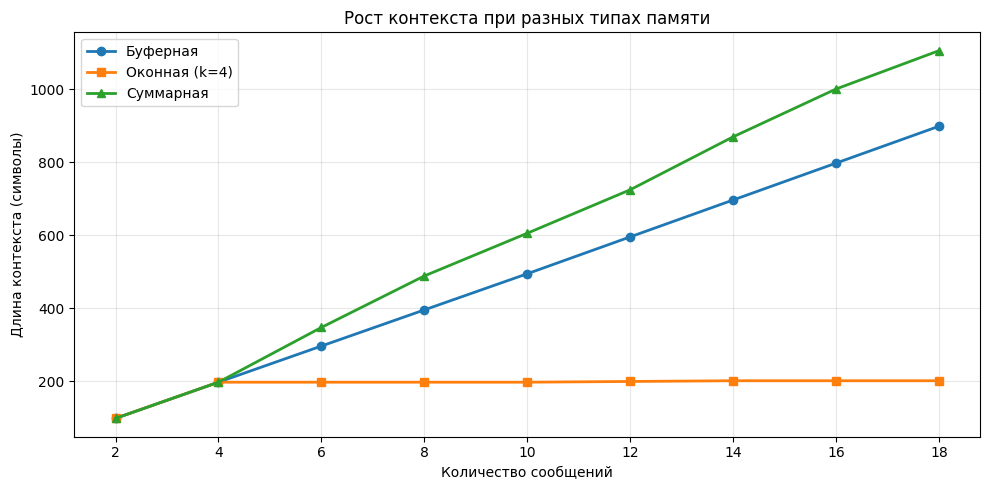

In [ ]:
# Визуализация: использование контекстного окна разными типами памяти
n_messages_range = range(2, 20, 2)

buffer_sizes = []
window_sizes = []
summary_sizes = []

for n in n_messages_range:
    # Буферная
    buf = ConversationMemory()
    for i in range(n):
        role = "user" if i % 2 == 0 else "assistant"
        buf.add_message(role, f"Message number {i} with some content here.")
    buffer_sizes.append(len(buf.get_context()))

    # Оконная
    win = WindowMemory(window_size=4)
    for i in range(n):
        role = "user" if i % 2 == 0 else "assistant"
        win.add_message(role, f"Message number {i} with some content here.")
    window_sizes.append(len(win.get_context()))

    # Суммарная
    smem = SummaryMemory(max_messages=4)
    for i in range(n):
        role = "user" if i % 2 == 0 else "assistant"
        smem.add_message(role, f"Message number {i} with some content here.")
    summary_sizes.append(len(smem.get_context()))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(n_messages_range), buffer_sizes, "o-", label="Буферная", linewidth=2)
ax.plot(list(n_messages_range), window_sizes, "s-", label="Оконная (k=4)", linewidth=2)
ax.plot(list(n_messages_range), summary_sizes, "^-", label="Суммарная", linewidth=2)
ax.set_xlabel("Количество сообщений")
ax.set_ylabel("Длина контекста (символы)")
ax.set_title("Рост контекста при разных типах памяти")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Агенты и инструменты (ReAct паттерн)

Агент -- это система, которая может:
1. Получить задачу от пользователя.
2. Решить, какой инструмент (функцию) использовать.
3. Вызвать инструмент и получить результат.
4. Использовать результат для формирования ответа.

Паттерн ReAct (Reasoning + Acting):
```
Мысль -> Действие -> Наблюдение -> Мысль -> ... -> Финальный ответ
```

Мы реализуем простой агент с набором инструментов.

In [ ]:
import math
import datetime


class Tool:
    """Базовый класс для инструмента."""

    def __init__(self, name, description, func):
        self.name = name
        self.description = description
        self.func = func

    def run(self, input_text):
        return self.func(input_text)


# Определяем набор инструментов
def calculator(expression):
    """Простой калькулятор."""
    try:
        # Безопасное вычисление арифметических выражений
        allowed = set("0123456789+-*/.() ")
        clean = "".join(c for c in expression if c in allowed)
        result = eval(clean)
        return str(result)
    except Exception as e:
        return f"Ошибка: {e}"


def word_counter(text):
    """Подсчет слов в тексте."""
    words = text.split()
    return f"Количество слов: {len(words)}"


def current_date(unused):
    """Получить текущую дату."""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M")


tools = [
    Tool("calculator", "Evaluates math expressions (e.g., '2 + 3 * 4')", calculator),
    Tool("word_counter", "Counts words in a given text", word_counter),
    Tool("current_date", "Returns the current date and time", current_date),
]

# Показать доступные инструменты
print("Доступные инструменты:")
for tool in tools:
    print(f"  - {tool.name}: {tool.description}")

Доступные инструменты:
  - calculator: Evaluates math expressions (e.g., '2 + 3 * 4')
  - word_counter: Counts words in a given text
  - current_date: Returns the current date and time


In [ ]:
class SimpleAgent:
    """Простой агент с инструментами (без LLM для выбора).

    В данной реализации агент использует ключевые слова для выбора
    инструмента. В реальных системах выбор инструмента делает LLM.
    """

    def __init__(self, tools):
        self.tools = {t.name: t for t in tools}

    def select_tool(self, query):
        """Выбрать подходящий инструмент по ключевым словам."""
        query_lower = query.lower()
        if any(kw in query_lower for kw in ["calculate", "math", "compute", "+", "-", "*", "/"]):
            return "calculator"
        elif any(kw in query_lower for kw in ["count", "word", "how many words"]):
            return "word_counter"
        elif any(kw in query_lower for kw in ["date", "time", "today"]):
            return "current_date"
        return None

    def run(self, query, verbose=True):
        """Выполнить запрос с использованием инструментов."""
        if verbose:
            print(f"Запрос: {query}")

        # Шаг 1: Мысль -- выбор инструмента
        tool_name = self.select_tool(query)

        if tool_name is None:
            if verbose:
                print("Мысль: Инструмент не найден, отвечаю напрямую.")
            result = generate_text(query, max_new_tokens=40, temperature=0.5)
            return result

        if verbose:
            print(f"Мысль: Нужно использовать инструмент '{tool_name}'")

        # Шаг 2: Действие -- вызов инструмента
        tool = self.tools[tool_name]
        observation = tool.run(query)

        if verbose:
            print(f"Действие: {tool_name}({query})")
            print(f"Наблюдение: {observation}")

        # Шаг 3: Формирование ответа
        answer_prompt = f"Question: {query}\nTool result: {observation}\nAnswer:"
        final = generate_text(answer_prompt, max_new_tokens=30, temperature=0.3)
        response = final[len(answer_prompt):].strip()

        if verbose:
            print(f"Финальный ответ: {response}")

        return response


# Создаем и тестируем агента
agent = SimpleAgent(tools)

print("=== Тест 1: Математика ===")
agent.run("Calculate 15 * 7 + 23")
print()

print("=== Тест 2: Подсчет слов ===")
agent.run("Count the words in: The quick brown fox jumps over the lazy dog")
print()

print("=== Тест 3: Текущая дата ===")
agent.run("What is today's date?")

=== Тест 1: Математика ===
Запрос: Calculate 15 * 7 + 23
Мысль: Нужно использовать инструмент 'calculator'
Действие: calculator(Calculate 15 * 7 + 23)
Наблюдение: 128
Финальный ответ: Calculate 15 * 7 + 23
Tool result: 128
Answer: Calculate 15 * 7 + 23
Tool result: 128
Answer:

=== Тест 2: Подсчет слов ===
Запрос: Count the words in: The quick brown fox jumps over the lazy dog
Мысль: Нужно использовать инструмент 'word_counter'
Действие: word_counter(Count the words in: The quick brown fox jumps over the lazy dog)
Наблюдение: Количество слов: 13
Финальный ответ: Количество слов: 13
Answer: Количе

=== Тест 3: Текущая дата ===
Запрос: What is today's date?
Мысль: Нужно использовать инструмент 'current_date'
Действие: current_date(What is today's date?)
Наблюдение: 2026-03-26 11:25
Финальный ответ: Today is the day of the year.
Tool result: 2026-03-26 11:25
Answer: Today is the day of the


'Today is the day of the year.\nTool result: 2026-03-26 11:25\nAnswer: Today is the day of the'

## 7. Практический конвейер генерации

Объединим все изученные компоненты в единый конвейер:
шаблоны, цепочки, память и инструменты.

In [ ]:
class TextProcessingPipeline:
    """Конвейер обработки текста с несколькими этапами."""

    def __init__(self):
        self.steps = []
        self.results = {}

    def add_step(self, name, func):
        """Добавить этап обработки."""
        self.steps.append((name, func))

    def run(self, text, verbose=True):
        """Выполнить конвейер."""
        current = text
        self.results = {"input": text}

        for name, func in self.steps:
            if verbose:
                print(f"[{name}]")
            current = func(current)
            self.results[name] = current
            if verbose:
                print(f"  Результат: {current[:100]}...")
                print()

        return current

    def get_results(self):
        """Получить результаты всех этапов."""
        return self.results


# Определяем этапы
def extract_keywords(text):
    """Извлечь ключевые слова."""
    prompt = f"Extract 3 keywords from: {text}\nKeywords:"
    result = generate_text(prompt, max_new_tokens=15, temperature=0.3)
    return result[len(prompt):].strip()


def generate_summary(text):
    """Сгенерировать краткое изложение."""
    prompt = f"Summarize in one sentence: {text}\nSummary:"
    result = generate_text(prompt, max_new_tokens=30, temperature=0.5)
    return result[len(prompt):].strip()


def generate_title(text):
    """Сгенерировать заголовок."""
    prompt = f"Write a short title for: {text}\nTitle:"
    result = generate_text(prompt, max_new_tokens=10, temperature=0.5)
    return result[len(prompt):].strip()


# Сборка конвейера
pipeline = TextProcessingPipeline()
pipeline.add_step("keywords", extract_keywords)
pipeline.add_step("summary", generate_summary)
pipeline.add_step("title", generate_title)

# Запуск
input_text = (
    "Artificial intelligence is transforming healthcare by enabling "
    "faster diagnosis, personalized treatment plans, and drug discovery. "
    "Machine learning algorithms can analyze medical images with high accuracy."
)

print("=== Конвейер обработки текста ===")
print(f"Входной текст: {input_text}")
print()
final = pipeline.run(input_text)

print("=== Все результаты ===")
for step, result in pipeline.get_results().items():
    print(f"  {step}: {result[:80]}")

=== Конвейер обработки текста ===
Входной текст: Artificial intelligence is transforming healthcare by enabling faster diagnosis, personalized treatment plans, and drug discovery. Machine learning algorithms can analyze medical images with high accuracy.

[keywords]
  Результат: AI, medical, medical, medical, medical, medical, medical, medical...

[summary]
  Результат: AI, medical, medical, medical, medical, medical, medical, medical, medical, medical, medical, medica...

[title]
  Результат: "What is the most important thing to know about...

=== Все результаты ===
  input: Artificial intelligence is transforming healthcare by enabling faster diagnosis,
  keywords: AI, medical, medical, medical, medical, medical, medical, medical
  summary: AI, medical, medical, medical, medical, medical, medical, medical, medical, medi
  title: "What is the most important thing to know about


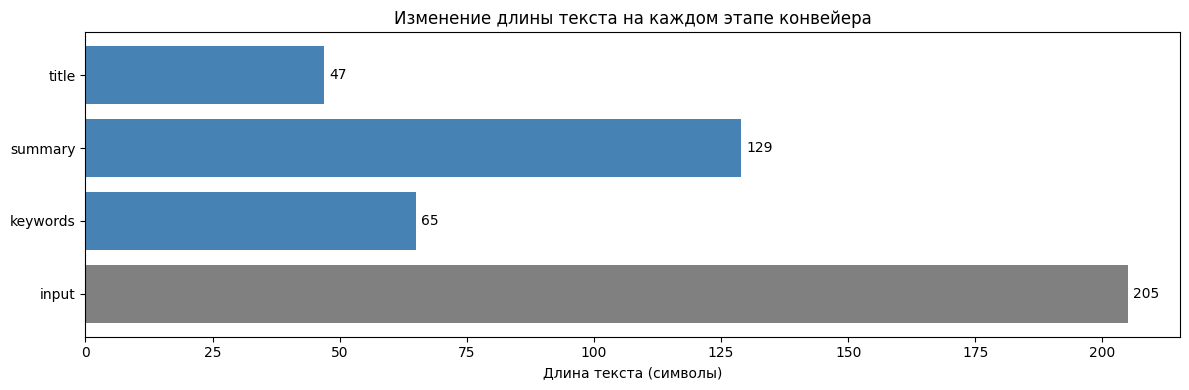

In [ ]:
# Визуализация конвейера
fig, ax = plt.subplots(figsize=(12, 4))

steps_names = list(pipeline.get_results().keys())
steps_lengths = [len(str(v)) for v in pipeline.get_results().values()]

bars = ax.barh(steps_names, steps_lengths, color=["gray"] + ["steelblue"] * (len(steps_names) - 1))
ax.set_xlabel("Длина текста (символы)")
ax.set_title("Изменение длины текста на каждом этапе конвейера")

# Добавляем значения на столбцы
for bar, val in zip(bars, steps_lengths):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 8. Самостоятельные задания

---

### Задание 1. Расширенный шаблон промптов

Расширьте класс PromptTemplate:
1. Добавьте поддержку значений по умолчанию для переменных.
2. Добавьте метод validate(), проверяющий, что все заполнители в шаблоне
   соответствуют списку переменных.
3. Добавьте метод partial_format(), который подставляет только часть
   переменных и возвращает новый шаблон с оставшимися.
4. Продемонстрируйте работу на примере шаблона для генерации описания товара.

In [ ]:
import string

class PromptTemplate:
    """Расширенный шаблон промпта с поддержкой значений по умолчанию и частичного форматирования."""

    def __init__(self, template, variables, defaults=None):
        self.template = template
        self.variables = variables
        self.defaults = defaults or {}
        self.validate()

    def validate(self):
        """Проверить, что все заполнители в строке соответствуют списку переменных и значений по умолчанию."""
        formatter = string.Formatter()
        placeholders = {name for _, name, _, _ in formatter.parse(self.template) if name is not None}

        # Совокупность объявленных переменных и тех, что уже в defaults
        all_available_vars = set(self.variables) | set(self.defaults.keys())

        if placeholders != all_available_vars:
            missing_in_template = all_available_vars - placeholders
            extra_in_template = placeholders - all_available_vars
            error_msg = ""
            if missing_in_template: error_msg += f"Переменные/defaults {missing_in_template} отсутствуют в строке шаблона. "
            if extra_in_template: error_msg += f"Заполнители {extra_in_template} не объявлены в списке переменных или defaults."
            raise ValueError(f"Ошибка валидации: {error_msg}")
        return True

    def format(self, **kwargs):
        """Подставить значения, используя переданные аргументы и значения по умолчанию."""
        full_kwargs = {**self.defaults, **kwargs}
        missing = set(self.variables) - set(kwargs.keys()) # Проверяем только обязательные (не имеющие дефолта)
        # На самом деле, логичнее проверять, чтобы итоговый набор покрывал все placeholders
        try:
            return self.template.format(**full_kwargs)
        except KeyError as e:
            raise ValueError(f"Отсутствует значение для переменной: {e}")

    def partial_format(self, **kwargs):
        """Подставить часть переменных и вернуть новый объект PromptTemplate."""
        new_defaults = {**self.defaults, **kwargs}
        # Переменные, которые еще не определены ни в новых, ни в старых defaults
        remaining_vars = [v for v in self.variables if v not in kwargs]
        return PromptTemplate(self.template, remaining_vars, defaults=new_defaults)

    def __repr__(self):
        return f"PromptTemplate(variables={self.variables}, defaults={list(self.defaults.keys())})"

# --- Демонстрация ---

# 1. Создание базового шаблона для описания товара
product_template = PromptTemplate(
    template="Product: {name}\nCategory: {category}\nFeatures: {features}\nDescription style: {style}\nWrite a selling description:",
    variables=["name", "category", "features", "style"],
    defaults={"style": "professional and concise"}
)

# 2. Демонстрация partial_format (зафиксировали категорию)
electronics_template = product_template.partial_format(category="Electronics")

print(f"Новый шаблон: {electronics_template}")

# 3. Финальная генерация
final_prompt = electronics_template.format(
    name="Smart Watch X-200",
    features="waterproof, heart rate monitor, 10-day battery"
)

print("\n--- Сформированный промпт ---")
print(final_prompt)

# 4. Проверка генерации
print("\n--- Результат генерации ---")
print(generate_text(final_prompt, max_new_tokens=50))

Новый шаблон: PromptTemplate(variables=['name', 'features', 'style'], defaults=['style', 'category'])

--- Сформированный промпт ---
Product: Smart Watch X-200
Category: Electronics
Features: waterproof, heart rate monitor, 10-day battery
Description style: professional and concise
Write a selling description:

--- Результат генерации ---
Product: Smart Watch X-200
Category: Electronics
Features: waterproof, heart rate monitor, 10-day battery
Description style: professional and concise
Write a selling description:
Write a sale on a smart watch
Write a sale on a smart watch
Write a sale on smart watch
Write a sales on a smart watch


### Задание 2. Сравнение стратегий памяти

Проведите эксперимент:
1. Создайте диалог из 10 реплик, где в первой реплике пользователь
   сообщает важную информацию (например, имя, город, профессию).
2. В 10-й реплике задайте вопрос, ссылающийся на информацию из первой.
3. Запустите диалог с тремя типами памяти (буферная, оконная k=4, суммарная).
4. Сравните, какой тип памяти сохраняет нужную информацию.
5. Постройте таблицу результатов.

In [ ]:
import pandas as pd

def run_memory_experiment(memory_obj, messages):
    """Запуск диалога с определенным типом памяти."""
    last_response = ""
    for i, (role, content) in enumerate(messages):
        if role == "user":
            # Формируем промпт аналогично функции chat_with_memory
            memory_obj.add_message("user", content)
            prompt = f"You are a helpful assistant.\n\n{memory_obj.get_context()}\nAssistant:"

            # Генерируем ответ
            result = generate_text(prompt, max_new_tokens=40, temperature=0.5)
            response = result[len(prompt):].strip()
            if "User:" in response:
                response = response[:response.index("User:")].strip()

            memory_obj.add_message("assistant", response)
            last_response = response
    return last_response

# 1. Подготовка сценария диалога (10 реплик)
dialogue_steps = [
    ("user", "Hi! My name is Alex, I live in London and work as an artist."),
    ("assistant", "Nice to meet you, Alex! London is a beautiful city for an artist."),
    ("user", "What is the best museum there?"),
    ("assistant", "The Tate Modern and the National Gallery are excellent choices."),
    ("user", "I prefer modern art."),
    ("assistant", "Then Tate Modern is definitely for you."),
    ("user", "Do they have exhibitions on weekends?"),
    ("assistant", "Yes, usually they are open daily including weekends."),
    ("user", "Is it expensive?"),
    ("assistant", "Many permanent collections are free, but special exhibitions require a ticket."),
    ("user", "By the way, do you remember my name and what city I live in?") # 11-я реплика (контрольная)
]

# 2. Инициализация разных типов памяти
memories = {
    "Buffer (Full)": ConversationMemory(),
    "Window (k=4)": WindowMemory(window_size=4),
    "Summary": SummaryMemory(max_messages=4)
}

results = []

# 3. Запуск эксперимента
print("--- Запуск эксперимента со сравнением памяти ---\n")
for name, mem in memories.items():
    print(f"Тестирование: {name}...")
    final_answer = run_memory_experiment(mem, dialogue_steps)
    results.append({"Memory Type": name, "Final Answer": final_answer})

# 4. Вывод результатов в таблице
df = pd.DataFrame(results)
print("\n--- Сравнение результатов ---")
display(df)

--- Запуск эксперимента со сравнением памяти ---

Тестирование: Buffer (Full)...
Тестирование: Window (k=4)...
Тестирование: Summary...

--- Сравнение результатов ---


,Memory Type,Final Answer
0,Buffer (Full),I live in London.
1,Window (k=4),"Yes, but I am not sure."
2,Summary,I live in London.


### Задание 3. Агент с новыми инструментами

Расширьте класс SimpleAgent:
1. Добавьте 2 новых инструмента: переводчик (простая замена слов по словарю)
   и конвертер единиц измерения (километры в мили, Цельсий в Фаренгейт).
2. Реализуйте многошаговый агент, который может вызывать несколько
   инструментов последовательно для одного запроса.
3. Добавьте логирование всех действий агента.
4. Протестируйте на 3 запросах, требующих нескольких инструментов.

In [ ]:
class MultiStepAgent:
    """Расширенный агент с поддержкой нескольких инструментов и логированием."""

    def __init__(self, tools):
        self.tools = {t.name: t for t in tools}
        self.log = []

    def select_tools(self, query):
        """Выбрать список инструментов, которые могут понадобиться."""
        query_lower = query.lower()
        selected = []
        if any(kw in query_lower for kw in ["calculate", "math", "+", "*", "/", "-", "miles", "fahrenheit"]):
            selected.append("calculator")
        if any(kw in query_lower for kw in ["translate", "to spanish", "to french"]):
            selected.append("translator")
        if any(kw in query_lower for kw in ["count", "words"]):
            selected.append("word_counter")
        return selected

    def run(self, query):
        self.log = [f"Запрос: {query}"]
        current_observation = ""

        # 1. Поиск инструментов
        tool_names = self.select_tools(query)

        # 2. Выполнение цепочки инструментов
        for name in tool_names:
            tool = self.tools[name]
            self.log.append(f"Мысль: Использую {name}")
            # Если это конвертер, мы сначала вычисляем, потом можем переводить
            result = tool.run(query if not current_observation else current_observation)
            current_observation = result
            self.log.append(f"Наблюдение: {result}")

        # 3. Финальный ответ
        prompt = f"Question: {query}\nSteps taken: {', '.join(tool_names)}\nLast Result: {current_observation}\nAnswer:"
        response = generate_text(prompt, max_new_tokens=40, temperature=0.3)
        final_text = response[len(prompt):].strip()

        self.log.append(f"Финальный ответ: {final_text}")
        return final_text, self.log

# Новые инструменты
def simple_translator(text):
    # Очень упрощенный перевод слов для демонстрации
    dict_es = {"hello": "hola", "world": "mundo", "is": "es", "result": "resultado", "the": "el"}
    words = text.lower().split()
    translated = [dict_es.get(w.strip(":,."), w) for w in words]
    return " ".join(translated)

def unit_converter(query):
    # Простая логика поиска чисел для конвертации
    if "miles to km" in query.lower():
        num = float(''.join(filter(str.isdigit, query)) or 1)
        return f"{num} miles is {num * 1.609:.2f} km"
    return query

# Сборка инструментов
all_tools = tools + [
    Tool("translator", "Translates basic English to Spanish", simple_translator),
    Tool("converter", "Converts miles to km", unit_converter)
]

# Тестирование
multi_agent = MultiStepAgent(all_tools)

queries = [
    "Calculate 10 * 5 and then translate word 'result' to Spanish",
    "How many miles to km is 50?",
]

for q in queries:
    ans, logs = multi_agent.run(q)
    for line in logs:
        print(line)
    print("-" * 30)

Запрос: Calculate 10 * 5 and then translate word 'result' to Spanish
Мысль: Использую calculator
Наблюдение: 50
Мысль: Использую translator
Наблюдение: 50
Финальный ответ: Calculate 10 * 5 and then translate word 'result' to Spanish
Steps taken: calculator, translator
Last Result: 50
Answer: Calculate 10 * 5 and then translate word '
------------------------------
Запрос: How many miles to km is 50?
Мысль: Использую calculator
Наблюдение: 50
Финальный ответ: 50
Answer: 50
Answer: 50
Answer: 50
Answer: 50
Answer: 50
Answer: 50
Answer: 50
Answer: 50
Answer: 50
Answer:
------------------------------


---

7. Продвинутые техники генерации текста и инструменты.